# UNet Training for Optic Disc/Cup Segmentation

This notebook trains a UNet model for segmenting optic disc and cup in fundus images.

## 1. Setup and Imports

In [2]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from training.train import train_model, plot_training_history

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


## 2. Training Configuration

In [3]:
# Training hyperparameters
config = {
    'root_dir': str(project_root),
    'num_epochs': 100,  # Increased from 50 to 100 epochs
    'batch_size': 16,  # Increased from 4 to better utilize GPU memory
    'learning_rate': 1e-4,
    'image_size': 256,  # Reduced to 256 to allow larger batch size
    'base_channels': 64,
    'num_workers': 4,
    'save_dir': str(project_root / 'checkpoints'),
    'filter_incomplete': True
}

print("Training Configuration:")
print("=" * 50)
for key, value in config.items():
    print(f"{key:20s}: {value}")
print("\nNote: Using class weights - Cup weight=2.0 to improve Cup segmentation")

Training Configuration:
root_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs          : 100
batch_size          : 16
learning_rate       : 0.0001
image_size          : 256
base_channels       : 64
num_workers         : 4
save_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints
filter_incomplete   : True

Note: Using class weights - Cup weight=2.0 to improve Cup segmentation


## 2b. Training Configuration with CLAHE (Alternative)

In [4]:
# Training hyperparameters with CLAHE
config_clahe = {
    'root_dir': str(project_root),
    'num_epochs': 100,
    'batch_size': 16,
    'learning_rate': 1e-4,
    'image_size': 256,
    'base_channels': 64,
    'num_workers': 4,
    'save_dir': str(project_root / 'checkpoints_clahe'),
    'filter_incomplete': True,
    'use_clahe': True  # Enable CLAHE for contrast enhancement
}

print("Training Configuration with CLAHE:")
print("=" * 50)
for key, value in config_clahe.items():
    print(f"{key:20s}: {value}")
print("\n✨ Using CLAHE (Contrast Limited Adaptive Histogram Equalization)")
print("   - Improves local contrast in fundus images")
print("   - Enhances disc/cup boundaries")
print("   - Cup weight=2.0 for better Cup segmentation")


Training Configuration with CLAHE:
root_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs          : 100
batch_size          : 16
learning_rate       : 0.0001
image_size          : 256
base_channels       : 64
num_workers         : 4
save_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_clahe
filter_incomplete   : True
use_clahe           : True

✨ Using CLAHE (Contrast Limited Adaptive Histogram Equalization)
   - Improves local contrast in fundus images
   - Enhances disc/cup boundaries
   - Cup weight=2.0 for better Cup segmentation


## 3. Train the Model

In [4]:
# Clear GPU cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU cache cleared")
    print(f"GPU memory allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"GPU memory reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")


GPU cache cleared
GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB


In [5]:
# Clear the dataset cache before training to ensure filter_incomplete works correctly
from data_loader.dataset import GlaucomaDataset
GlaucomaDataset._split_cache.clear()

# Train the model
model, history = train_model(**config_clahe)


Using device: cuda
Using CLAHE for contrast enhancement

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Initializing model...
Model parameters: 31,043,651

Starting training for 100 epochs...

Epoch 1/100
--------------------------------------------------------------------------------


Training: 100%|█| 116/116 [00:42<00:00,  2.72it/s, loss=0.3769, iou_bg=0.7428, iou_disc=0.
Validation: 100%|█| 25/25 [00:03<00:00,  7.69it/s, loss=0.4093, iou_bg=0.7561, iou_disc=0.



Epoch 1 Summary:
  Train Loss: 0.5217 | Val Loss: 0.3889
  Train IoU - BG: 0.6304, Disc: 0.5574, Cup: 0.5038
  Val IoU   - BG: 0.7487, Disc: 0.6579, Cup: 0.6041
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3889)

Epoch 2/100
--------------------------------------------------------------------------------


Training: 100%|█| 116/116 [00:42<00:00,  2.74it/s, loss=0.3113, iou_bg=0.7714, iou_disc=0.
Validation: 100%|█| 25/25 [00:03<00:00,  7.55it/s, loss=0.3285, iou_bg=0.7961, iou_disc=0.



Epoch 2 Summary:
  Train Loss: 0.3842 | Val Loss: 0.3307
  Train IoU - BG: 0.7031, Disc: 0.6613, Cup: 0.6350
  Val IoU   - BG: 0.7816, Disc: 0.6811, Cup: 0.6065
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3307)

Epoch 3/100
--------------------------------------------------------------------------------


...


Epoch 98 Summary:
  Train Loss: 0.1512 | Val Loss: 0.1609
  Train IoU - BG: 0.8932, Disc: 0.8465, Cup: 0.7918
  Val IoU   - BG: 0.8804, Disc: 0.8479, Cup: 0.7796
  Learning Rate: 0.000013

Epoch 99/100
--------------------------------------------------------------------------------


Training: 100%|█| 116/116 [00:42<00:00,  2.74it/s, loss=0.1463, iou_bg=0.8895, iou_d
Validation: 100%|█| 25/25 [00:03<00:00,  7.58it/s, loss=0.1611, iou_bg=0.8823, iou_d



Epoch 99 Summary:
  Train Loss: 0.1508 | Val Loss: 0.1609
  Train IoU - BG: 0.8937, Disc: 0.8482, Cup: 0.7941
  Val IoU   - BG: 0.8818, Disc: 0.8480, Cup: 0.7803
  Learning Rate: 0.000006

Epoch 100/100
--------------------------------------------------------------------------------


Training: 100%|█| 116/116 [00:42<00:00,  2.74it/s, loss=0.2048, iou_bg=0.9032, iou_d
Validation: 100%|█| 25/25 [00:03<00:00,  7.55it/s, loss=0.1588, iou_bg=0.8863, iou_d



Epoch 100 Summary:
  Train Loss: 0.1517 | Val Loss: 0.1585
  Train IoU - BG: 0.8931, Disc: 0.8477, Cup: 0.7933
  Val IoU   - BG: 0.8842, Disc: 0.8464, Cup: 0.7782
  Learning Rate: 0.000006
  ✓ Saved checkpoint

Training completed!
Best validation loss: 0.1585


## 4. Visualize Training Progress

Plot saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history.png


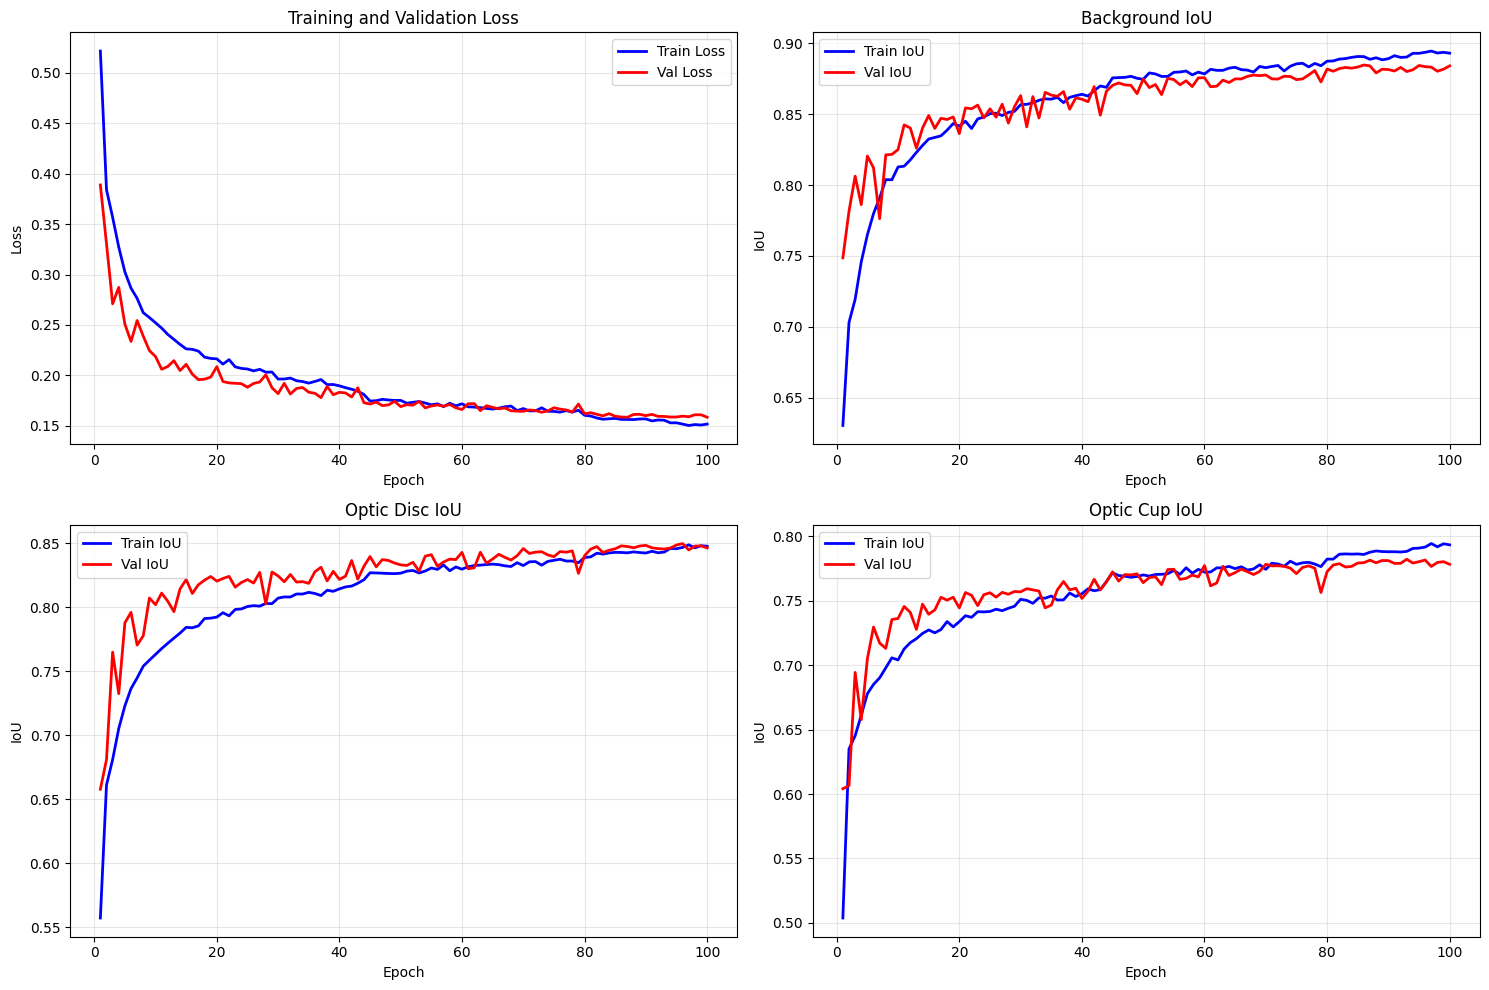

In [ ]:
# Plot training history (CLAHE model)
fig = plot_training_history(
    history, 
    save_path=str(project_root / 'results' / 'training_history_clahe.png')
)
plt.show()


## 5. Print Final Metrics

In [7]:
print("\n" + "=" * 80)
print("FINAL TRAINING RESULTS")
print("=" * 80)

final_epoch = len(history['train_loss'])
print(f"\nTotal Epochs: {final_epoch}")

print("\nFinal Training Metrics:")
print(f"  Loss:        {history['train_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['train_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['train_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['train_iou_cup'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"  Loss:        {history['val_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['val_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['val_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['val_iou_cup'][-1]:.4f}")

print("\nBest Validation Loss:")
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])
print(f"  Epoch: {best_epoch}")
print(f"  Loss:  {best_val_loss:.4f}")

print("\n" + "=" * 80)


FINAL TRAINING RESULTS

Total Epochs: 100

Final Training Metrics:
  Loss:        0.1517
  IoU (BG):    0.8931
  IoU (Disc):  0.8477
  IoU (Cup):   0.7933

Final Validation Metrics:
  Loss:        0.1585
  IoU (BG):    0.8842
  IoU (Disc):  0.8464
  IoU (Cup):   0.7782

Best Validation Loss:
  Epoch: 87
  Loss:  0.1585



## 6. Save Training History

In [ ]:
import json

# Save history as JSON (CLAHE model)
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True, parents=True)

history_path = results_dir / 'training_history_clahe.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print(f"Training history saved to: {history_path}")


Training history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history.json


## 7. Visualize Predictions on Test Images

Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_clahe/best_model.pth
Loading test dataset...
Filtering incomplete masks...
Loading test dataset...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TEST split: 396 samples
Test dataset size: 396
  Filtered out 234 images with incomplete masks
TEST split: 396 samples
Test dataset size: 396
Sample 78: IoU Disc=0.909, IoU Cup=0.753
Sample 277: IoU Disc=0.904, IoU Cup=0.818
Sample 250: IoU Disc=0.837, IoU Cup=0.864
Sample 55: IoU Disc=0.930, IoU Cup=0.920
Sample 78: IoU Disc=0.909, IoU Cup=0.753
Sample 277: IoU Disc=0.904, IoU Cup=0.818
Sample 250: IoU Disc=0.837, IoU Cup=0.864
Sample 55: IoU Disc=0.930, IoU Cup=0.920

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/predictions_visualization_clahe.png

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/predictions_visualization_clahe.png


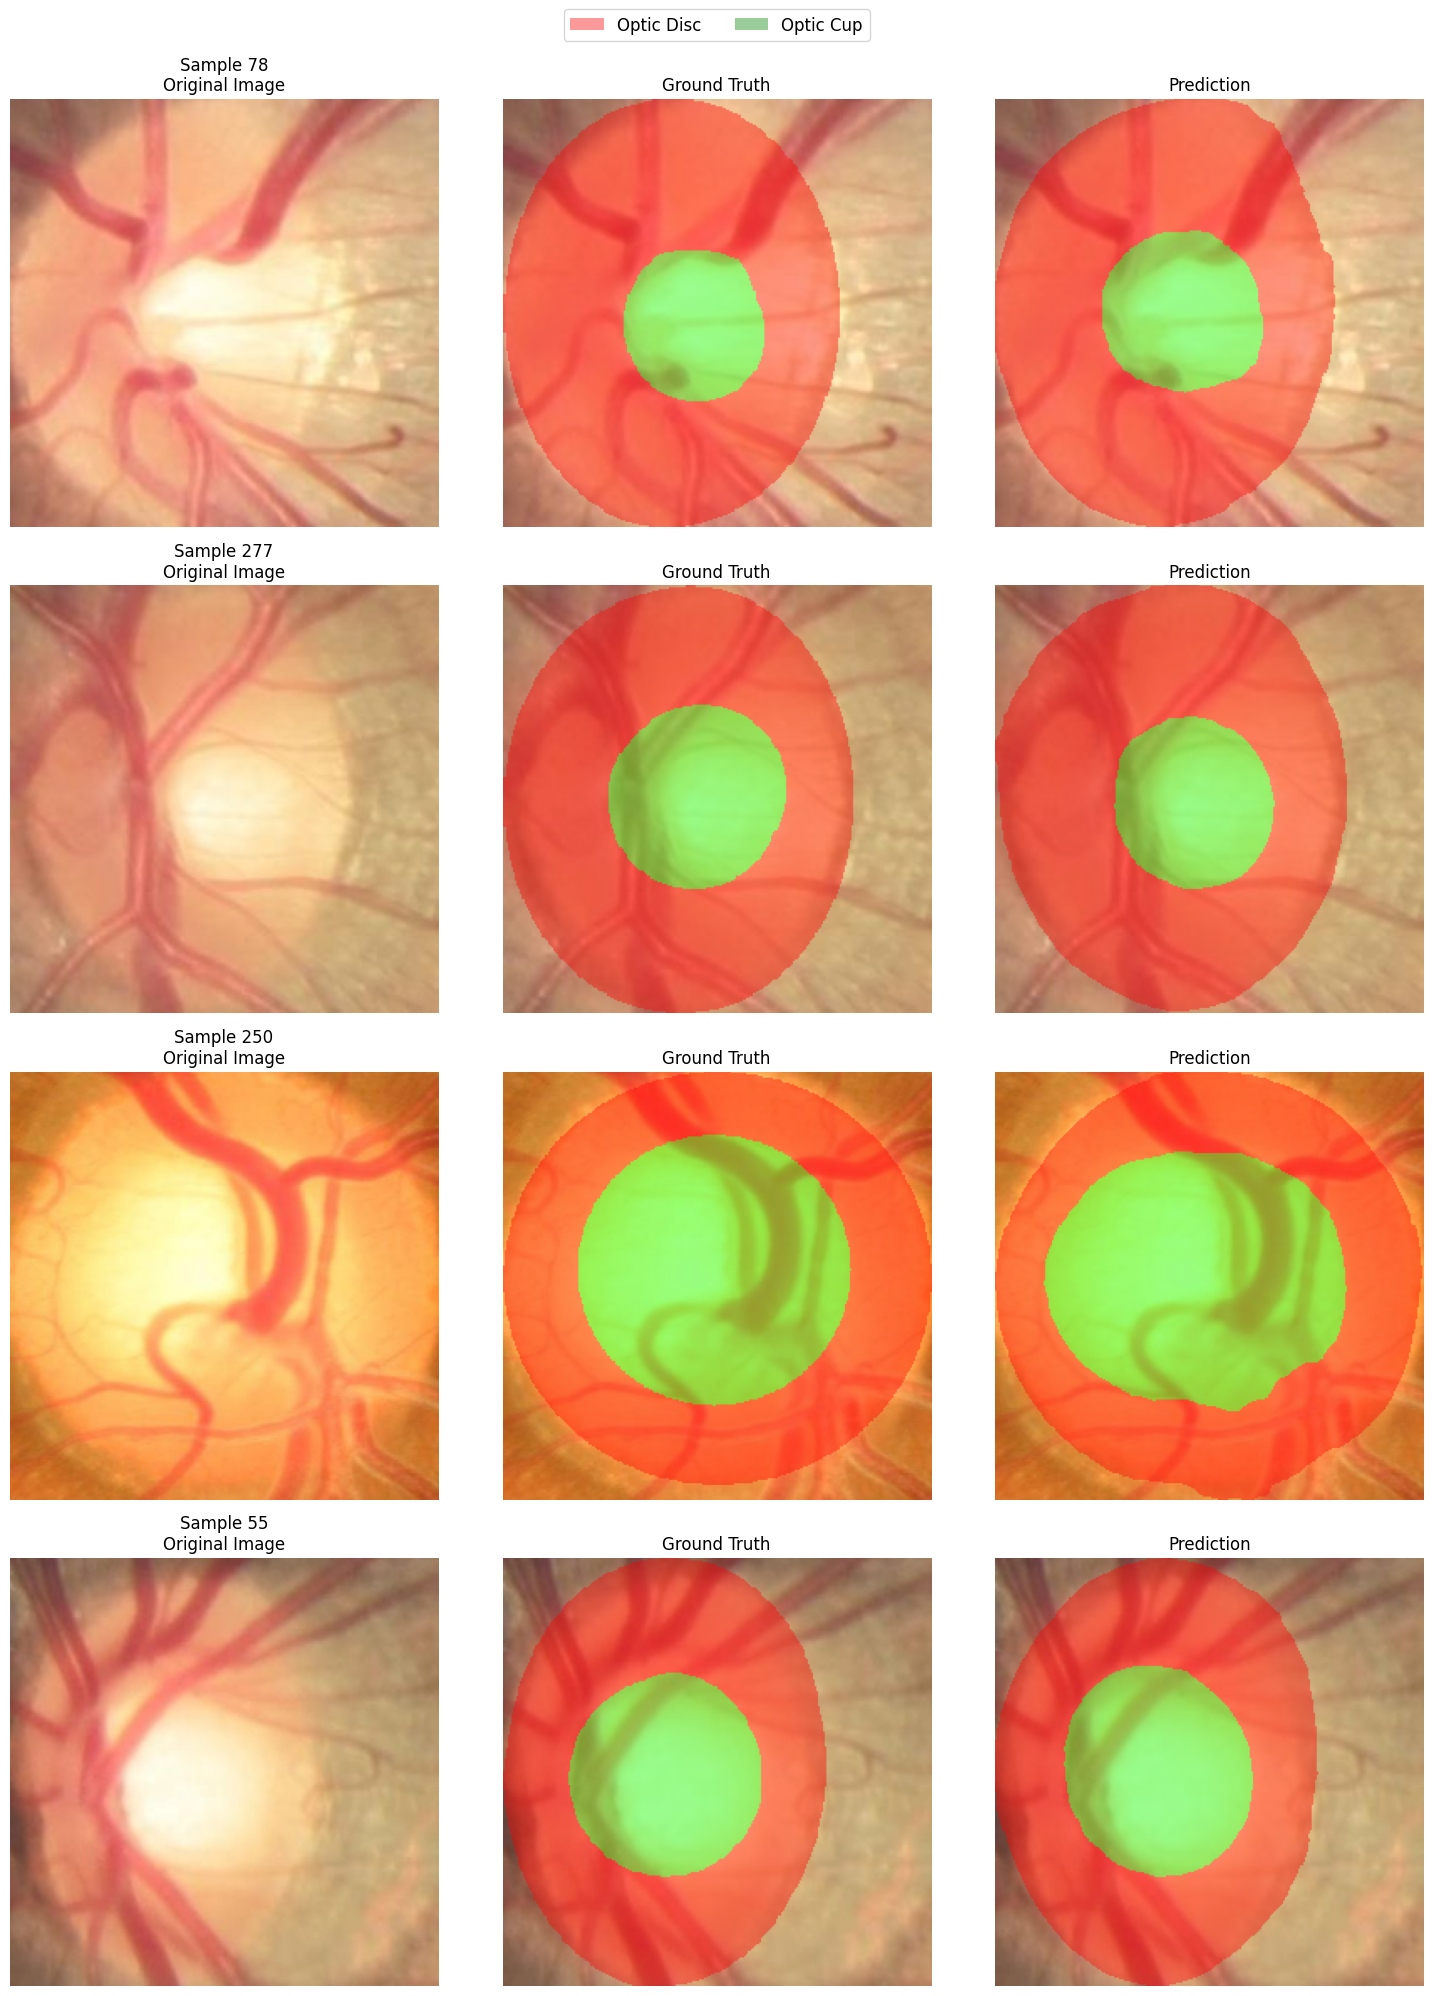

In [5]:
from utils.visualize_predictions import visualize_predictions

# Visualize predictions on test images (CLAHE model)
fig = visualize_predictions(
    checkpoint_path=str(project_root / 'checkpoints_clahe' / 'best_model.pth'),
    root_dir=str(project_root),
    num_samples=4,
    save_path=str(project_root / 'results' / 'predictions_visualization_clahe.png'),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    image_size=config_clahe['image_size'],
    seed=42
)


## 8. Evaluate on Complete Test Set

In [6]:
from utils.evaluate_test_set import evaluate_test_set

# Evaluate on entire test set (CLAHE model)
test_results = evaluate_test_set(
    checkpoint_path=str(project_root / 'checkpoints_clahe' / 'best_model.pth'),
    root_dir=str(project_root),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    image_size=config_clahe['image_size'],
    seed=42,
    save_path=str(project_root / 'results' / 'test_evaluation_clahe.json')
)


Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_clahe/best_model.pth
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396

Evaluating test set...
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396

Evaluating test set...


Evaluating: 100%|██████████| 396/396 [00:05<00:00, 78.13it/s]


TEST SET EVALUATION RESULTS

Test Set Size: 396 images

--- IoU Scores ---
Background:  0.8836 ± 0.0599
Optic Disc:  0.8421 ± 0.0883
Optic Cup:   0.7801 ± 0.1106
Mean IoU:    0.8353

--- Dice Scores ---
Background:  0.9371 ± 0.0358
Optic Disc:  0.9111 ± 0.0669
Optic Cup:   0.8716 ± 0.0791
Mean Dice:   0.9066

--- Pixel Accuracy ---
Overall:     0.9153 ± 0.0460

--- Detailed Statistics ---

Optic Disc IoU:
  Min:    0.0600
  Median: 0.8649
  Max:    0.9409

Optic Cup IoU:
  Min:    0.2360
  Median: 0.8074
  Max:    0.9510


Results saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/test_evaluation_clahe.json


## 9. Visualize Worst Predictions (Failure Cases)

Using device: cuda
Loading model from /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_clahe/best_model.pth
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396

Evaluating all samples to find worst cup predictions...
Loading test dataset...
TEST split: 396 samples
Test dataset size: 396

Evaluating all samples to find worst cup predictions...


Evaluating: 100%|██████████| 396/396 [00:05<00:00, 77.76it/s]



Sample 52: Disc IoU=0.254, Cup IoU=0.236
Sample 209: Disc IoU=0.744, Cup IoU=0.292
Sample 366: Disc IoU=0.060, Cup IoU=0.299
Sample 224: Disc IoU=0.833, Cup IoU=0.364
Sample 150: Disc IoU=0.694, Cup IoU=0.429
Sample 332: Disc IoU=0.645, Cup IoU=0.435
Sample 113: Disc IoU=0.754, Cup IoU=0.481
Sample 91: Disc IoU=0.823, Cup IoU=0.484

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/worst_predictions_cup_clahe.png

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/worst_predictions_cup_clahe.png


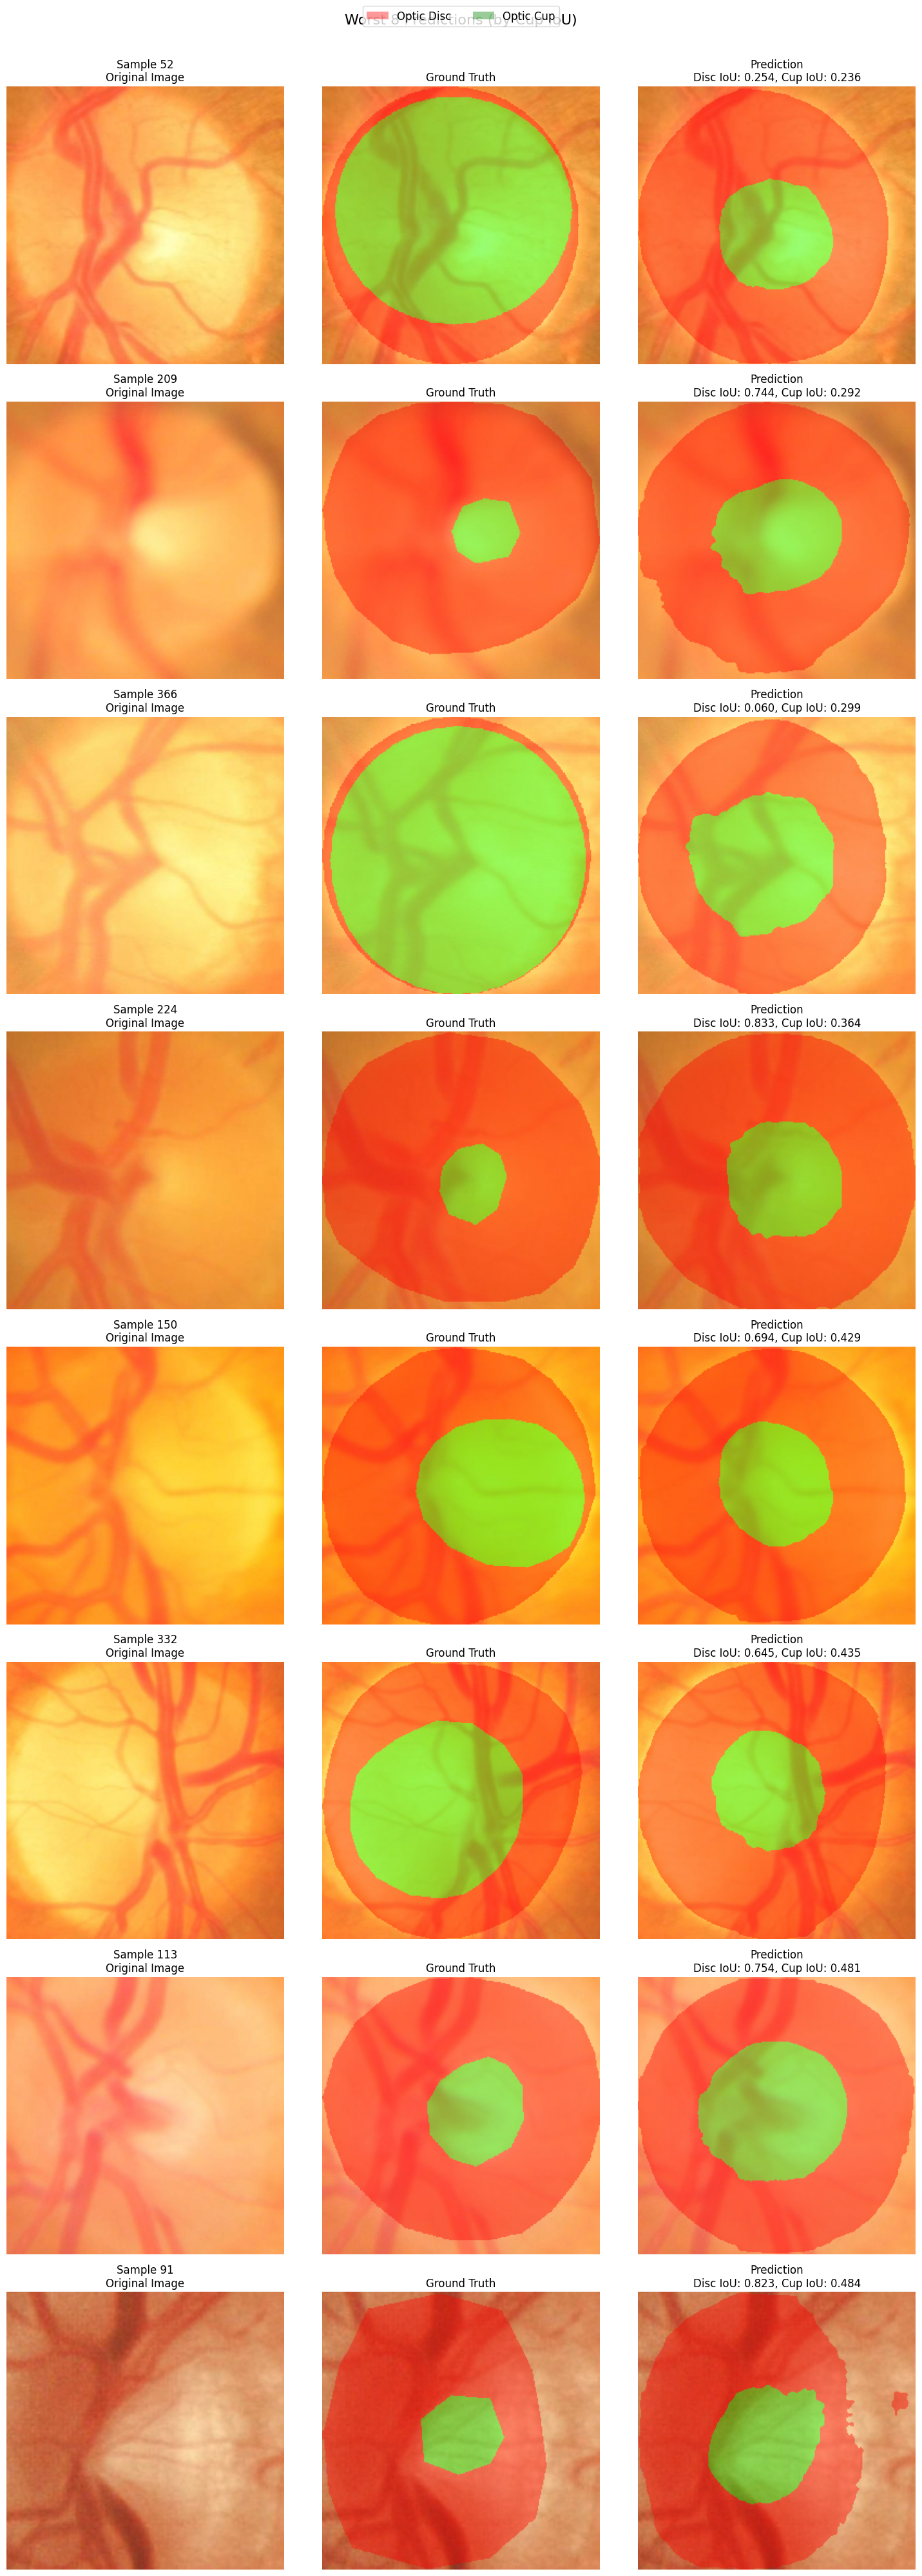

In [7]:
from utils.visualize_worst_predictions import visualize_worst_predictions

# Visualize worst predictions based on Cup IoU (CLAHE model)
fig_worst, worst_samples = visualize_worst_predictions(
    checkpoint_path=str(project_root / 'checkpoints_clahe' / 'best_model.pth'),
    root_dir=str(project_root),
    num_worst=8,
    metric='cup',  # Can be 'cup', 'disc', or 'mean'
    save_path=str(project_root / 'results' / 'worst_predictions_cup_clahe.png'),
    device='cuda' if torch.cuda.is_available() else 'cpu',
    image_size=config_clahe['image_size'],
    seed=42
)


## 10. Visualize CLAHE Effect

TEST split: 396 samples
Test dataset size: 396

Visualization saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/clahe_comparison.png


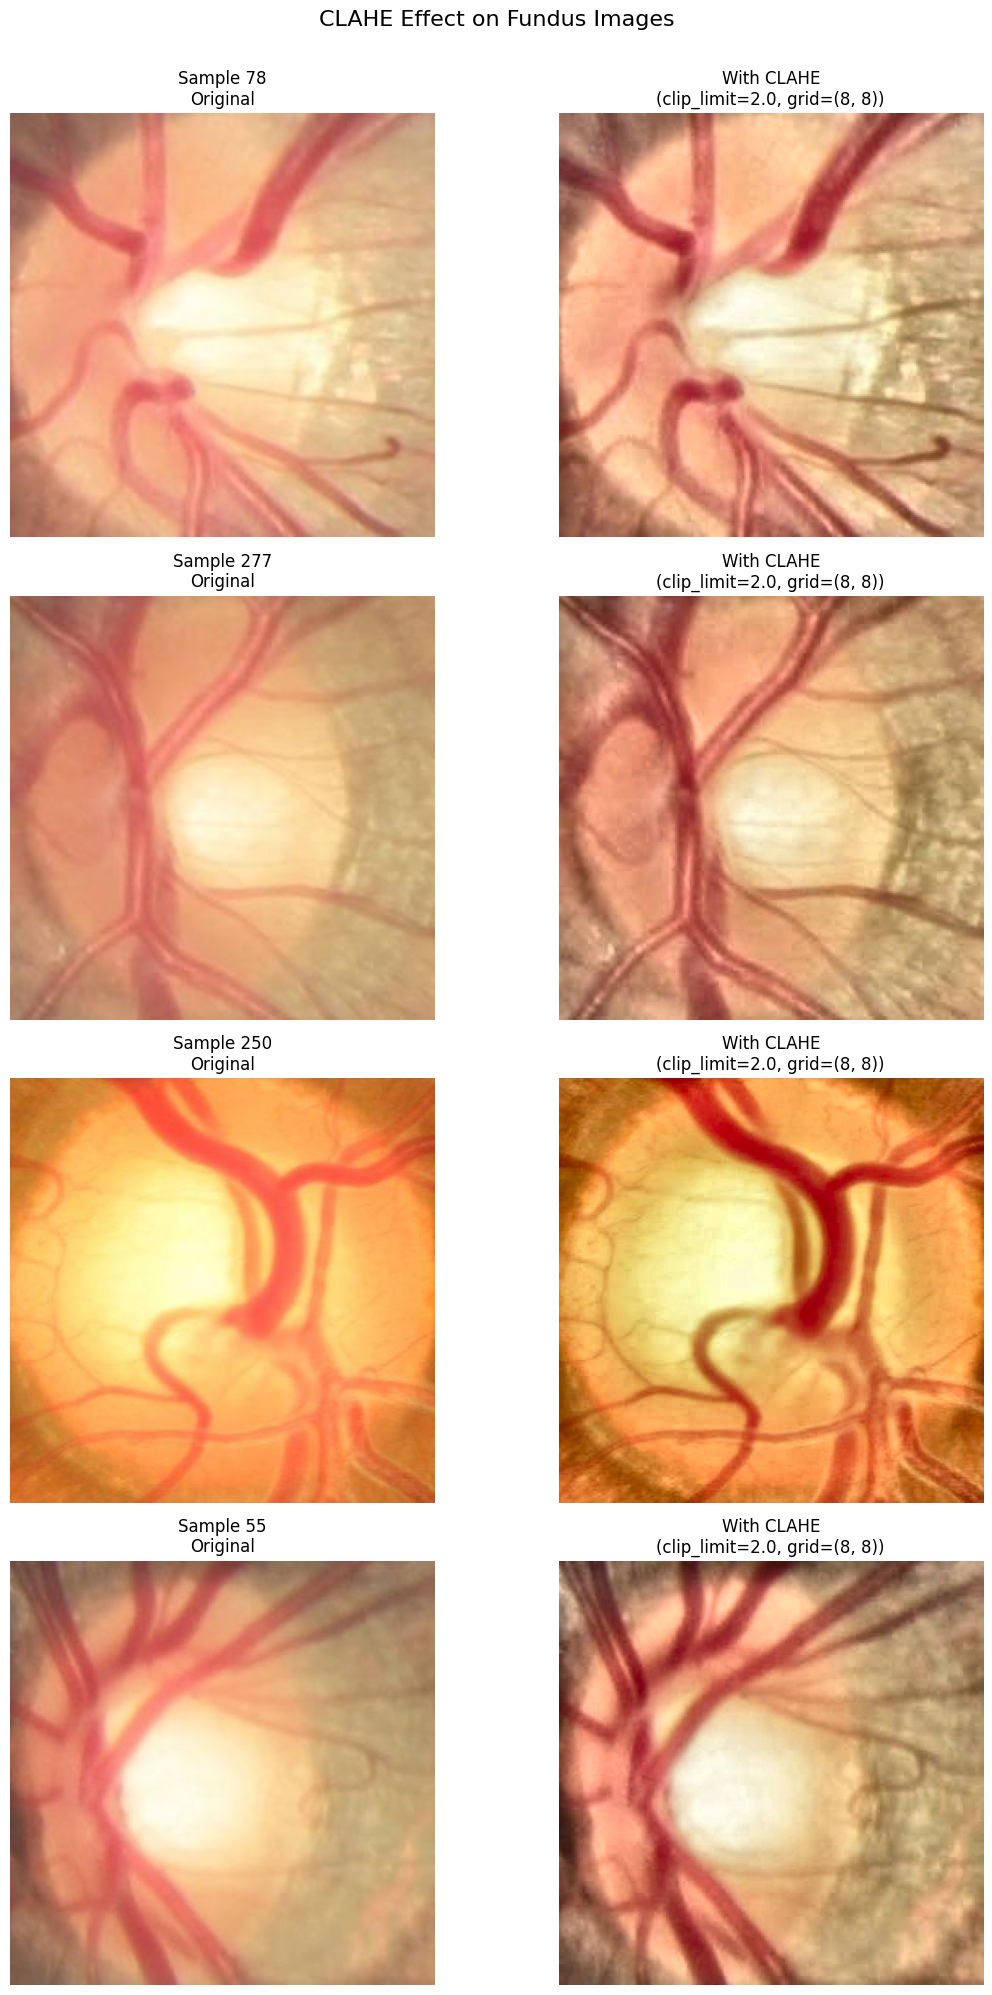

In [12]:
from utils.visualize_clahe import visualize_clahe_effect

# Visualize CLAHE effect on sample images
fig_clahe = visualize_clahe_effect(
    root_dir=str(project_root),
    num_samples=4,
    save_path=str(project_root / 'results' / 'clahe_comparison.png'),
    seed=42,
    clip_limit=2.0,
    tile_grid_size=(8, 8)
)
